In [1]:
#Compute Effective Receptive fields by chain rules, using encoded backward functions. 

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from tqdm import tqdm
import time
import torch.nn.functional as F
from sklearn.metrics import r2_score as R2
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2
from copy import deepcopy
import utils
from unet import UNet_nobatchnorm
from scipy.stats import pearsonr
#JU's addtion to automate inputs and outputs
import helper_functions as hf
torch.cuda.set_device(0)
import os
def save_fn(var_input_list, var_output_list):
    var_input_join  = '_and_'.join(var_input_list)
    var_output_join = '_and_'.join(var_output_list)
    return '{}_to_{}'.format(var_input_join, var_output_join)

In [3]:
print(torch.__version__)
print(torch.version.cuda)

2.5.1
12.6


In [4]:
Nbase = 16

In [5]:
!nvidia-smi #GPU usage should be maxed out during training; tune batch_size according to that

Fri Mar 13 15:37:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.65.06              Driver Version: 580.65.06      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   43C    P0             67W /  500W |       4MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [6]:
root_dir = '/work/uo0780/u241359/project_tide_synergy/data/'
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print ('Running on ', device)

Ntrain = np.sum([nc.dimensions['time_counter'].size for nc in nctrains], axis = 0)
Ntest = np.sum([nc.dimensions['time_counter'].size for nc in nctest], axis = 0)

print('number of training records:', Ntrain)
print('number of testing records:', Ntest)

numTrainFiles = len(nctrains)
numRecsFile = nctrains[0].dimensions['time_counter'].size #How many snapshots in time in each data set there is
print (numRecsFile)


def preload_data(nctrains, total_records):
    #total_records = Ntrain#sum(nc.dimensions['time_counter'].size for nc in nctrains)
    #dimensions of data of the nc file.
    max_height = 722
    max_width = 258
    all_input_data = np.zeros((total_records, N_inp, max_height, max_width))*np.nan
    all_output_data = np.zeros((total_records, N_out, max_height, max_width))*np.nan
    current_index = 0
    for ncindex, ncdata in enumerate(nctrains):
        num_recs = ncdata.dimensions['time_counter'].size
        rec_slice = slice(current_index, current_index + num_recs)
        
        for ind, var_name in enumerate(var_input_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            # print('data_slice shape:')
            # print(data_slice.shape)        
            #all_input_data[rec_slice, ind, :, :] = data_slice
            #For some variables, the dimensions in (x, y) may be smaller than (max_height, max_width). Changing the code so that it adapts them.
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_input_data[rec_slice, ind, :slice_height, :slice_width] = data_slice
    

        for ind, var_name in enumerate(var_output_names):
            data_slice = np.squeeze(ncdata.variables[var_name])
            #all_output_data[rec_slice, ind, :, :] = data_slice
            # Get the actual dimensions of data_slice
            slice_height, slice_width = data_slice.shape[-2], data_slice.shape[-1]
            # Place data_slice into the corresponding slice of all_input_data
            all_output_data[rec_slice, ind, :slice_height, :slice_width] = data_slice

        current_index += num_recs
        
    return all_input_data, all_output_data
    
# Modify the loadtrain function to pull data from preloaded memory
def loaddata_preloaded_train(index, batch_size, all_input_data, all_output_data):
    rec_slice = slice(index, index + batch_size)
    lim = 720
    width = 256
    yslice = slice(0, lim)
    xslice = slice(0, width)
    # print('rec_slice is:')
    # print(rec_slice)
    # print('mean of squared values of loaded input data:')
    # print("{0:0.32f}".format(np.nanmean(all_input_data[rec_slice, :, yslice, xslice]**2)))
    return (all_input_data[rec_slice, :, yslice, xslice], 
            all_output_data[rec_slice, :, yslice, xslice])
#Load test data as one single batch
def loaddata_preloaded_test(all_input_data, all_output_data):
    #rec_slice = slice(index, index + batch_size)
    lim = 720
    width = 256
    yslice = slice(0, lim)
    xslice = slice(0, width)
    # print('rec_slice is:')
    # print(rec_slice)
    # print('mean of squared values of loaded input data:')
    # print("{0:0.32f}".format(np.nanmean(all_input_data[rec_slice, :, yslice, xslice]**2)))
    return (all_input_data[:, :, yslice, xslice], 
            all_output_data[:, :, yslice, xslice])


def load_variable(ncdata, ncindex, variable, rec_slice, yslice, xslice):
    data_squeezed = np.squeeze(ncdata[ncindex].variables[variable])
    return data_squeezed[rec_slice, yslice, xslice]


# def loadtest():
#     var_input = np.ones([150, N_inp, 720, 256])
#     var_output = np.ones([150, N_out, 720, 256])

#     for ind, var_name in enumerate(var_input_names):
#         data_squeezed = np.squeeze(nctest.variables[var_name])
#         var_input[:, ind, :, :] = data_squeezed[rectest_slice, ytest_slice, xtest_slice]
#     for ind, var_name in enumerate(var_output_names):
#         data_squeezed = np.squeeze(nctest.variables[var_name])
#         var_output[:, ind, :, :] = data_squeezed[rectest_slice, ytest_slice, xtest_slice]
#     return var_input, var_output


def totorch(x):
    return torch.tensor(x, dtype=torch.float32).cuda()



Running on  cuda:0
number of training records: 600
number of testing records: 150
150


In [7]:
vi1 = 'ssh_ins'

vo1 = 'ssh_cos'
vo2 = 'ssh_sin'

save_fn_prefix  = 'any_{}_{}{}_nobatchnorm'.format(vi1, vo1, vo2)

var_input_names = [vi1]
var_output_names = [vo1, vo2]

N_inp = len(var_input_names)
N_out = len(var_output_names)


# ---- Saved checkpoint ----
dr = '/work/uo0780/u241359/project_tide_synergy/trainedmodels_forpaper'
os.makedirs(dr, exist_ok=True)
fstr = f'{save_fn_prefix}_rp_0'
PATH_TO_PTH  = dr + f'/{fstr}.pth'

model = UNet_nobatchnorm(N_inp, N_out, bilinear=True, Nbase=Nbase).cuda()
state = torch.load(PATH_TO_PTH, map_location="cuda")
model.load_state_dict(state)
model.eval()
print("Loaded checkpoint:", PATH_TO_PTH)

#Get test data (same way as before)
root_dir = '/work/uo0780/u241359/project_tide_synergy/data/'
nctrains, nctest = hf.load_data_from_nc_as_lists(root_dir)

Ntrain = np.sum([nc.dimensions['time_counter'].size for nc in nctrains], axis=0)
Ntest  = np.sum([nc.dimensions['time_counter'].size for nc in nctest], axis=0)

# names must match training
var_input_names  = ['ssh_ins']
var_output_names = ['ssh_cos', 'ssh_sin']
N_inp = len(var_input_names)
N_out = len(var_output_names)

# preload
all_train_input, all_train_output = preload_data(nctrains, Ntrain)
all_test_input,  all_test_output  = preload_data(nctest,  Ntest)

# normalize EXACTLY like training
mean_input  = np.nanmean(np.concatenate((all_train_input, all_test_input), axis=0), axis=(0,2,3))
mean_output = np.nanmean(np.concatenate((all_train_output, all_test_output), axis=0), axis=(0,2,3))

all_train_input  = all_train_input  - mean_input[None, :, None, None]
all_test_input   = all_test_input   - mean_input[None, :, None, None]
all_train_output = all_train_output - mean_output[None, :, None, None]
all_test_output  = all_test_output  - mean_output[None, :, None, None]

var_input  = np.nanmean((np.concatenate((all_train_input, all_test_input), axis=0))**2, axis=(0,2,3))
var_output = np.nanmean((np.concatenate((all_train_output, all_test_output), axis=0))**2, axis=(0,2,3))

all_train_input  = all_train_input  / np.sqrt(var_input[None, :, None, None])
all_test_input   = all_test_input   / np.sqrt(var_input[None, :, None, None])
all_train_output = all_train_output / np.sqrt(var_output[None, :, None, None])
all_test_output  = all_test_output  / np.sqrt(var_output[None, :, None, None])

inp_test, out_test = loaddata_preloaded_test(all_test_input, all_test_output)
with torch.no_grad():
    inp_test = totorch(inp_test)   # [Ntest, Cin, 720, 256] on GPU


/tmp/ipykernel_843605/181805293.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(PATH_TO_PTH, map_location="cuda")


Loaded checkpoint: /work/uo0780/u241359/project_tide_synergy/trainedmodels_forpaper/any_ssh_ins_ssh_cosssh_sin_nobatchnorm_rp_0.pth


In [8]:
#Compute the radius (cumulative mass radius) of ERF

def erf_radii_cumulative(erf2d, center, ps=(0.5, 0.9), eps=1e-12):
    E = np.asarray(erf2d, dtype=np.float64)
    H, W = E.shape
    y0, x0 = center
    tot = E.sum()
    if tot < eps:
        return {p: np.nan for p in ps}
    w = E / tot
    yy, xx = np.indices((H, W))
    d = np.sqrt((yy - y0)**2 + (xx - x0)**2)
    order = np.argsort(d.ravel())
    d_sorted = d.ravel()[order]
    w_sorted = w.ravel()[order]
    cdf = np.cumsum(w_sorted)
    out = {}
    for p in ps:
        k = np.searchsorted(cdf, p, side="left")
        k = min(k, len(d_sorted)-1)
        out[p] = float(d_sorted[k])
    return out


def erf_onepixel_over_snapshots_cuda(model, inp_test_cuda, out_ch, y0, x0, snap_indices):
    """
    Compute ERF map for ONE output pixel (y0,x0) and ONE output channel out_ch,
    averaged over snapshots in snap_indices.

    ERF(u,v) = sum_k | d y[out_ch,y0,x0] / d x[k,u,v] |
    """
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    N, Cin, H, W = inp_test_cuda.shape
    device = inp_test_cuda.device
    erf_accum = torch.zeros((H, W), device=device, dtype=torch.float32)

    for idx in snap_indices:
        x = inp_test_cuda[idx:idx+1].detach().clone().requires_grad_(True)  # [1,Cin,H,W]
        y = model(x)  # [1,Cout,H,W]
        s = y[0, out_ch, y0, x0]  # scalar probe at one pixel

        model.zero_grad(set_to_none=True)
        if x.grad is not None:
            x.grad.zero_()
        s.backward()

        g = x.grad.detach().abs().sum(dim=1)[0]  # [H,W] on GPU
        erf_accum += g

        del x, y, s, g

    erf_mean = (erf_accum / float(len(snap_indices))).detach().cpu().numpy()
    return erf_mean

def radii_maps_patches_centerpixel(model, inp_test_cuda, snap_indices, py=20, px=20, ps=(0.5, 0.9, 0,95, 0.99)):
    """
    Returns r_maps[p] on the PATCH GRID (ny x nx), where each patch uses the ERF of its center pixel.
    """
    N, Cin, H, W = inp_test_cuda.shape

    y_starts = list(range(0, H, py))
    x_starts = list(range(0, W, px))
    ny, nx = len(y_starts), len(x_starts)

    r_maps = {p: np.full((ny, nx), np.nan, dtype=np.float32) for p in ps}

    for iy, y0_patch in enumerate(y_starts):
        y1_patch = min(y0_patch + py, H)
        yc = (y0_patch + y1_patch - 1) // 2

        for ix, x0_patch in enumerate(x_starts):
            x1_patch = min(x0_patch + px, W)
            xc = (x0_patch + x1_patch - 1) // 2

            # ERF per output channel, then average the ERF maps (your preferred definition)
            erf0 = erf_onepixel_over_snapshots_cuda(model, inp_test_cuda, out_ch=0, y0=yc, x0=xc, snap_indices=snap_indices)
            erf1 = erf_onepixel_over_snapshots_cuda(model, inp_test_cuda, out_ch=1, y0=yc, x0=xc, snap_indices=snap_indices)
            erf_avg = 0.5 * (erf0 + erf1)

            radii = erf_radii_cumulative(erf_avg, center=(yc, xc), ps=ps)
            for p in ps:
                r_maps[p][iy, ix] = radii[p]

    return r_maps
    
def patch_slices(H=720, W=256, py=20, px=20):
    ys = list(range(0, H, py))
    xs = list(range(0, W, px))
    for iy, y0 in enumerate(ys):
        for ix, x0 in enumerate(xs):
            yslice = slice(y0, min(y0+py, H))
            xslice = slice(x0, min(x0+px, W))
            yc = (yslice.start + yslice.stop - 1) // 2
            xc = (xslice.start + xslice.stop - 1) // 2
            yield iy, ix, yslice, xslice, (yc, xc), len(ys), len(xs)

def radii_maps_patches(model, inp_test_cuda, snap_indices, py=20, px=20, ps=(0.5,0.9)):
    N, Cin, H, W = inp_test_cuda.shape
    # Determine patch grid size
    tmp = list(patch_slices(H, W, py, px))
    ny, nx = tmp[0][5], tmp[0][6]

    r_maps = {p: np.full((ny, nx), np.nan, dtype=np.float32) for p in ps}

    for iy, ix, ysl, xsl, center, _, _ in tmp:
        # ERF per channel then average the ERF maps (your preferred definition)
        erf0 = erf_patch_over_snapshots(model, inp_test_cuda, out_ch=0, yslice=ysl, xslice=xsl, snap_indices=snap_indices)
        erf1 = erf_patch_over_snapshots(model, inp_test_cuda, out_ch=1, yslice=ysl, xslice=xsl, snap_indices=snap_indices)
        erf_avg = 0.5*(erf0 + erf1)

        radii = erf_radii_cumulative(erf_avg, center=center, ps=ps)
        for p in ps:
            r_maps[p][iy, ix] = radii[p]

    return r_maps  # each is [ny,nx]


def patchgrid_to_full_block(r_patch, H=720, W=256, py=20, px=20):
    """
    r_patch: [ny,nx] patch grid (from radii_maps_patches)
    Returns r_full: [H,W] where each patch value is filled into its pixel area.
    """
    r_full = np.full((H, W), np.nan, dtype=np.float32)

    iy = 0
    for y0 in range(0, H, py):
        y1 = min(y0 + py, H)
        ix = 0
        for x0 in range(0, W, px):
            x1 = min(x0 + px, W)
            r_full[y0:y1, x0:x1] = r_patch[iy, ix]
            ix += 1
        iy += 1

    return r_full
    

In [9]:
# Choose snapshots included in the ERF computation: 
snap_indices = list(range(0, 150, 5))  # 0,5,10,...,145 (30 snapshots)

start = time.time()

r_maps = radii_maps_patches_centerpixel(model, inp_test, snap_indices, py=5, px=5, ps=(0.5,0.9, 0.95, 0.99))

end = time.time()
print(end - start)

r50_patch = r_maps[0.5]
r99_patch = r_maps[0.9]

# Block-fill to full 720x256 grid (your function)
r50_full_block = patchgrid_to_full_block(r50_patch, H=720, W=256, py=5, px=5)
r99_full_block = patchgrid_to_full_block(r99_patch, H=720, W=256, py=5, px=5)


2425.6918857097626


In [12]:
nt, _, ny, nx= np.shape(inp_test)

dx = 4000 #Grid resolution is 4 km
Lx = nx*dx
Ly = ny*dx
print (Ly)

#axes used for plotting only
x_axis = np.arange(0, Lx, dx)/1000 # in km
y_axis = np.arange(0, Ly, dx)/1000
extent = [np.min(x_axis), np.max(x_axis), np.min(y_axis), np.max(y_axis)]


2880000


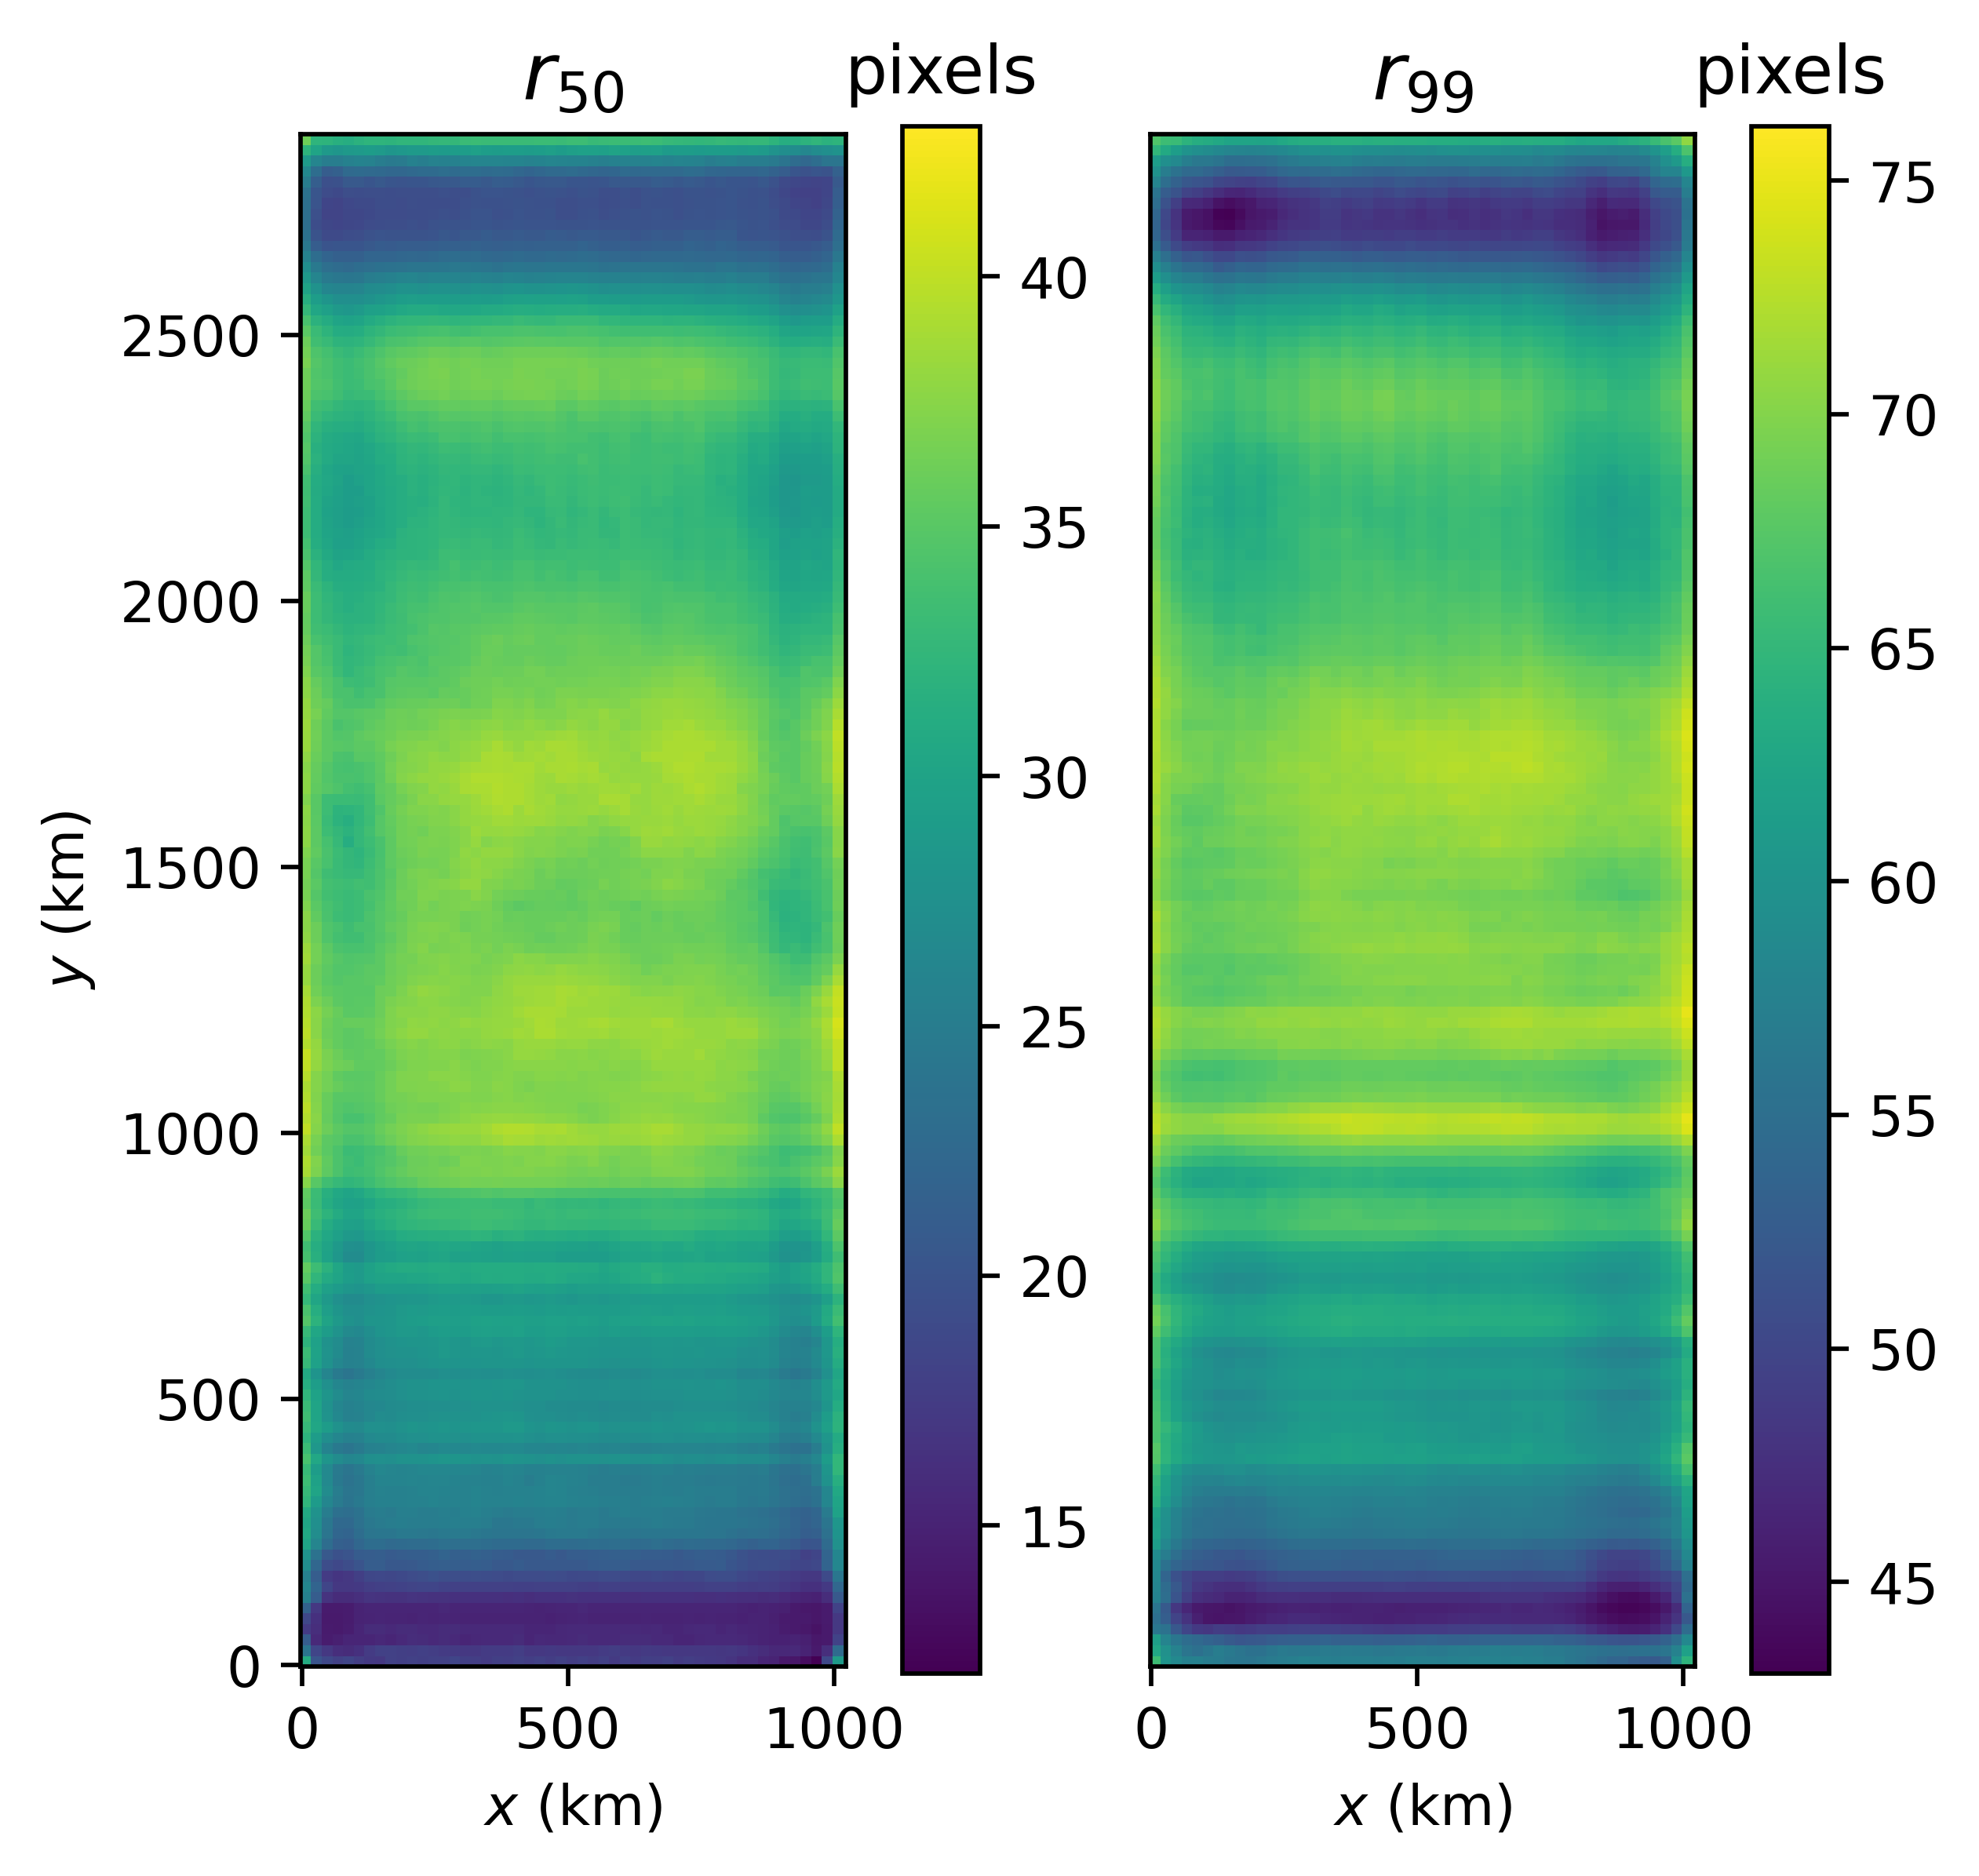

In [13]:
cmap_ERF = 'viridis'

fig, (ax1, ax2) = plt.subplots(1, 2,figsize = (5,5))
fig.set_dpi(512)

#clims = (np.min(r50), np.max(r99))

im1 = ax1.pcolor(x_axis, y_axis, r50_full_block, cmap=cmap_ERF)
ax1.set_title(r'$r_{50}$',fontsize ='x-large')
cbar = fig.colorbar(im1, ax = ax1, pad=0.08)
cbar.ax.set_title('pixels', fontsize='large', pad=6)

im2 = ax2.pcolor(x_axis, y_axis, r99_full_block, cmap=cmap_ERF)#, clim =clims)
ax2.set_title(r'$r_{99}$',fontsize ='x-large')
cbar = fig.colorbar(im2, ax = ax2, pad=0.08)
cbar.ax.set_title('pixels', fontsize='large', pad=6)

ax2.get_yaxis().set_visible(False)


ax1.set_xlabel(r'$x$ (km)') 
ax1.set_ylabel(r'$y$ (km)') 
ax2.set_xlabel(r'$x$ (km)') 

ax1.set_aspect(1)
ax2.set_aspect(1)

plt.show()

figfolder = '/work/uo0780/u241359/project_tide_synergy/figures_remote/'

fig.savefig(figfolder+'ERFradius.png', bbox_inches='tight',dpi=512)

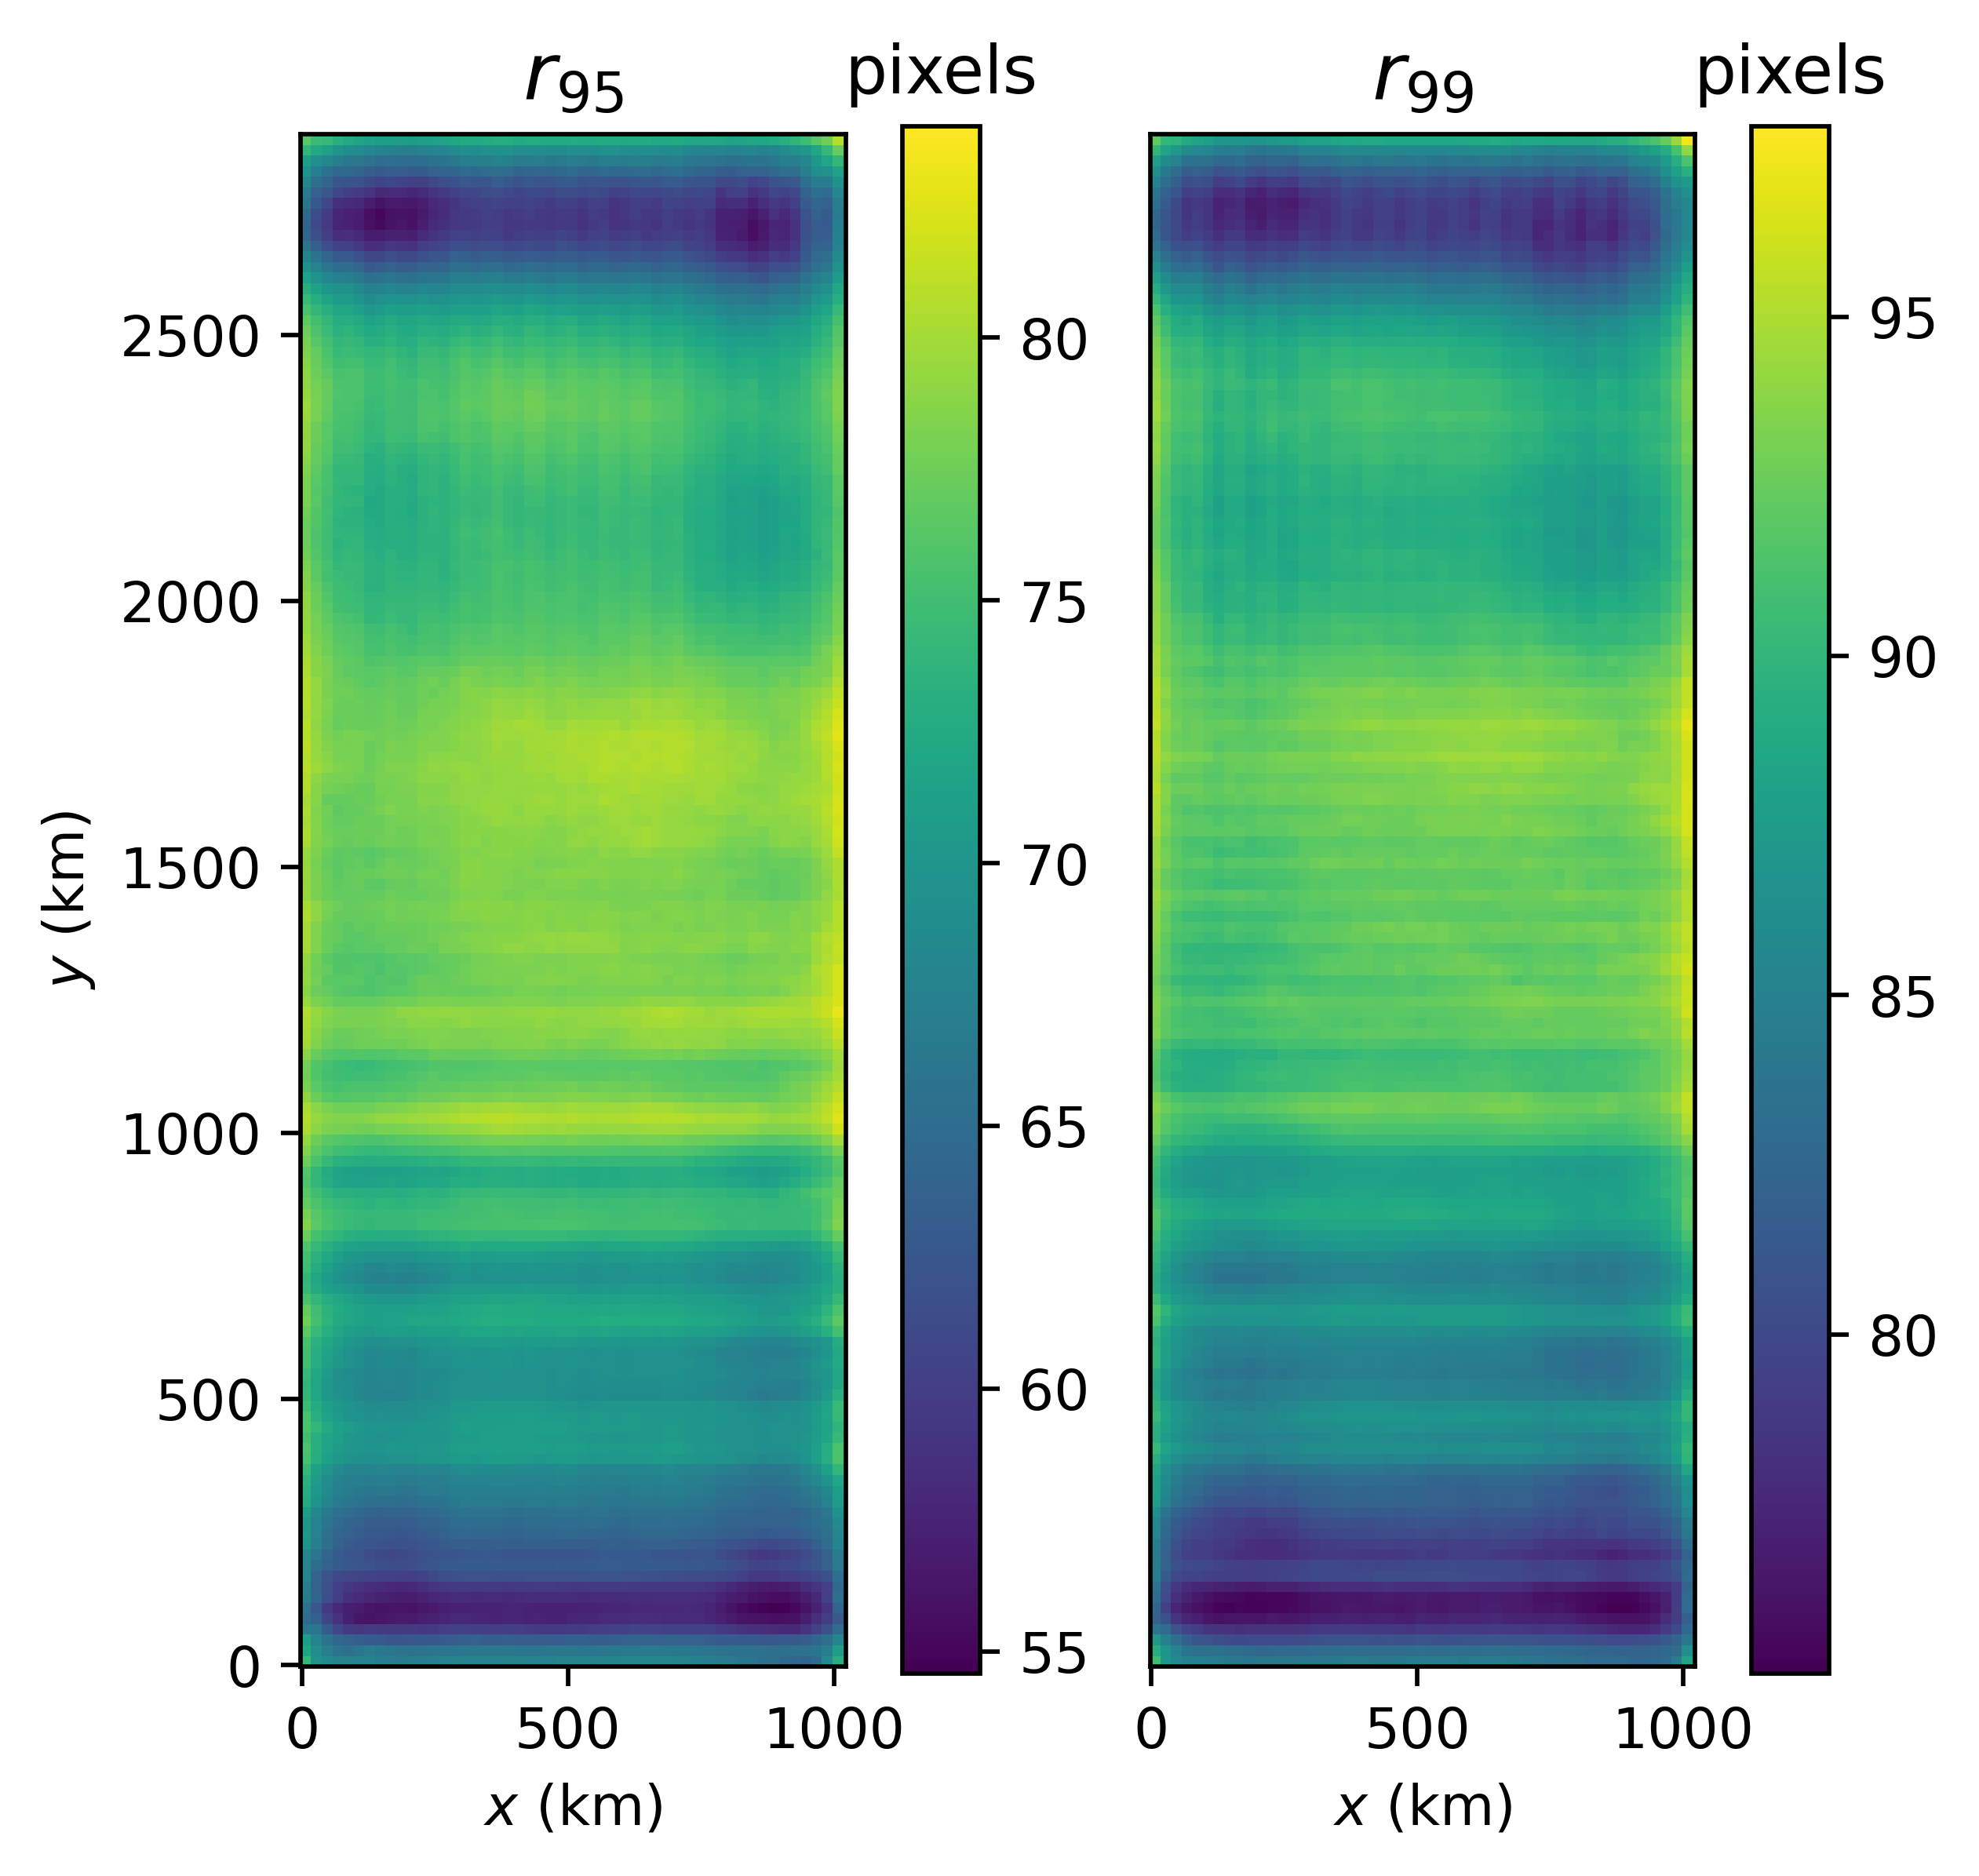

In [14]:
r95_patch = r_maps[0.95]
r99_patch = r_maps[0.99]

# Block-fill to full 720x256 grid (your function)
r95_full_block = patchgrid_to_full_block(r95_patch, H=720, W=256, py=5, px=5)
r99_full_block = patchgrid_to_full_block(r99_patch, H=720, W=256, py=5, px=5)



fig, (ax1, ax2) = plt.subplots(1, 2,figsize = (5,5))
fig.set_dpi(512)

#clims = (np.min(r95), np.max(r99))

im1 = ax1.pcolor(x_axis, y_axis, r95_full_block, cmap=cmap_ERF)
ax1.set_title(r'$r_{95}$',fontsize ='x-large')
cbar = fig.colorbar(im1, ax = ax1, pad=0.08)
cbar.ax.set_title('pixels', fontsize='large', pad=6)

im2 = ax2.pcolor(x_axis, y_axis, r99_full_block, cmap=cmap_ERF)#, clim =clims)
ax2.set_title(r'$r_{99}$',fontsize ='x-large')
cbar = fig.colorbar(im2, ax = ax2, pad=0.08)
cbar.ax.set_title('pixels', fontsize='large', pad=6)

ax2.get_yaxis().set_visible(False)


ax1.set_xlabel(r'$x$ (km)') 
ax1.set_ylabel(r'$y$ (km)') 
ax2.set_xlabel(r'$x$ (km)') 

ax1.set_aspect(1)
ax2.set_aspect(1)

plt.show()

figfolder = '/work/uo0780/u241359/project_tide_synergy/figures_remote/'

fig.savefig(figfolder+'ERFradius.png', bbox_inches='tight',dpi=512)

In [15]:
r95_full_block.shape

(720, 256)

In [22]:
bottom_slice = slice(0,256)
mid_slice = slice(232, 488)
top_slice = slice(464, 720)

print(np.mean(r95_full_block[mid_slice]))
print(np.mean(r95_full_block[bottom_slice])) #These statistics contain the sponge layer
print(np.mean(r95_full_block[top_slice]))


upjet_half_slice = slice(128,256)
downjet_half_slice = slice(464, 592)
print(np.mean(r95_full_block[upjet_half_slice]))
print(np.mean(r95_full_block[downjet_half_slice]))


78.095726
68.77841
71.41131
72.40546
74.97811


In [ ]:
outdir = "/work/uo0780/u241359/project_tide_synergy/ERF"
os.makedirs(outdir, exist_ok=True)

px=5
py=5
np.save(f"{outdir}/r50_patch_py{py}_px{px}_ns{len(snap_indices)}.npy", r50_patch)
np.save(f"{outdir}/r90_patch_py{py}_px{px}_ns{len(snap_indices)}.npy", r90_patch)
np.save(f"{outdir}/r95_patch_py{py}_px{px}_ns{len(snap_indices)}.npy", r95_patch)
np.save(f"{outdir}/r99_patch_py{py}_px{px}_ns{len(snap_indices)}.npy", r99_patch)